# Compositional Distributed Alignment Search for Nested NLI Causal Graphs

*A CS 221M walkthrough notebook — independent research framing.*

This notebook implements and explains **Distributed Alignment Search (DAS)** ([Geiger et al. 2023](https://arxiv.org/abs/2303.02536)) on a sequence of progressively harder NLI causal models, culminating in a **compositional** intervention on MQNLI's nested causal graph.

**What we show:**

1. **The simplest case.** On a controlled lexical NLI task, DAS recovers an interpretable single high-level variable (`lexical_relation`) in GPT-2 with IIA substantially above random-source and wrong-variable controls.
2. **A second variable.** The same method finds a separate intervention site for `monotonicity` (the upward/downward feature that flips `FORWARD ↔ REVERSE` under negation).
3. **Composition.** On MQNLI's 33-variable nested causal graph, two independently-trained DAS subspaces compose: joint interchange interventions on `NegP` and `QP_O` produce the symbolic counterfactual label.
4. **Calibration.** A random-init GPT-2 control shows that nontrivial IIA can be obtained without any learned task structure, illustrating the concern raised by [Makelov et al.](https://openreview.net/forum?id=Ebt7JgMHv1) and [Sutter et al.](https://arxiv.org/abs/2502.20914).

**Why this matters.** DAS sits at the intersection of causal abstraction and mechanistic interpretability: it asks whether a low-level neural representation plays the same causal role as a hypothesized high-level variable, even when the relevant information is distributed across neurons rather than localized to a discrete neuron set. Composition is the next natural test: if the model encodes *multiple* high-level variables that the symbolic model treats compositionally, the learned subspaces should also compose.

---

### Runtime expectations (Colab T4)

| Section | What runs | ~time |
|---|---|---|
| 1–4 | Lexical NLI: causal model + dataset construction | 1 min |
| 5 | Fine-tune GPT-2 on lexical NLI | 3 min |
| 6–7 | Activation patching + single-variable DAS (`lexical_relation`) | 10 min |
| 8 | Monotonicity — 2nd variable | 5 min |
| 9–11 | MQNLI: GPT-2 fine-tune → DAS on `QP_S` then `NegP` | 30 min |
| 12 | Composition: `do(NegP=src_A, QP_O=src_B)` | 8 min |
| 13 | Calibration: random-init GPT-2 control | 3 min |

**Total ~60 minutes on a T4.** Each section saves CSVs to `outputs/tables/` and figures to `outputs/figures/` for the final report.

## 0. Bootstrap

Run this cell once at the top of every session. On Colab it clones the repo, installs pinned deps, downloads the MQNLI signature JSONs, and changes the working directory. Locally it just verifies you're in the right place.

After this cell finishes:
- `import nli_das` works
- the repo working tree is at `cs221m-final/`
- `outputs/{figures,tables}/` exist

In [1]:
# ── Bootstrap ───────────────────────────────────────────────────────────────
import os, sys, subprocess
from pathlib import Path

REPO_URL  = "https://github.com/aquantumreality/cs221m-final.git"
REPO_NAME = "cs221m-final"

os.environ["USE_TF"] = "0"
os.environ["TRANSFORMERS_NO_TF"] = "1"
os.environ["TOKENIZERS_PARALLELISM"] = "false"
os.environ["PYTORCH_ENABLE_MPS_FALLBACK"] = "1"

IN_COLAB = "google.colab" in sys.modules or Path("/content").exists()

if IN_COLAB:
    repo_root = Path("/content") / REPO_NAME
    if not repo_root.exists():
        subprocess.check_call(["git", "clone", REPO_URL, str(repo_root)])
    os.chdir(repo_root)
else:
    # Local: walk up to find the repo root
    for cand in [Path.cwd(), *Path.cwd().parents]:
        if (cand / "nli_das").is_dir() and (cand / "requirements.txt").exists():
            os.chdir(cand)
            break
    else:
        raise FileNotFoundError("Could not find cs221m-final repo root.")

# Install dependencies. pyvene sometimes needs the git version if the PyPI build is stale.
subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "-r", "requirements.txt"])
try:
    import pyvene  # noqa: F401
except ImportError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q",
                           "git+https://github.com/stanfordnlp/pyvene.git"])

# MQNLI signature files (needed for sections 8+). Skipped silently if already present.
TUTORIAL_DATA = Path("tutorial_data")
TUTORIAL_DATA.mkdir(exist_ok=True)
_MQNLI_FILES = [
    "mqnli_q_projectivity.json",
    "mqnli_neg_signature.json",
    "mqnli_empty_signature.json",
    "mqnli_cont_signature.json",
    "mqnli_neg_cont_signature.json",
]
_BASE = "https://raw.githubusercontent.com/stanfordnlp/pyvene/main/tutorials/advanced_tutorials/tutorial_data/"
for fn in _MQNLI_FILES:
    target = TUTORIAL_DATA / fn
    if not target.exists():
        subprocess.run(["curl", "-sL", _BASE + fn, "-o", str(target)], check=False)

# Output dirs
Path("outputs/figures").mkdir(parents=True, exist_ok=True)
Path("outputs/tables").mkdir(parents=True, exist_ok=True)

print("Repo root:", Path.cwd())
print("Restart runtime if new packages were installed, then re-run from this cell.")


nnsight is not detected. Please install via 'pip install nnsight' for nnsight backend.
Repo root: /content/cs221m-final
Restart runtime if new packages were installed, then re-run from this cell.


In [2]:
pip install nnsight

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 272.5/272.5 kB 13.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.0/60.0 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 82.1/82.1 kB 5.1 MB/s eta 0:00:00


In [3]:
# ── Library imports + device/seed ──────────────────────────────────────────
import json, gc, copy
from collections import Counter
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

from transformers import AutoTokenizer, AutoModelForCausalLM

import nli_das
from nli_das import (
    LexicalCausalModel,
    LEXICAL_PAIRS, UPWARD_TEMPLATES, DOWNWARD_TEMPLATES, DEFAULT_TEMPLATES,
    NLIExample, generate_examples, label_distribution, relation_distribution,
    build_counterfactual_dataset, build_random_source_dataset,
    build_wrong_variable_dataset, pair_level_split,
    LabelVerbalizer, compute_iia,
    make_das_config, train_das_alignment, evaluate_das_iia,
    run_patching_sweep, save_patching_heatmap_from_df,
)

SEED   = 0
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.manual_seed(SEED); np.random.seed(SEED)
print(f"DEVICE = {DEVICE}")


DEVICE = cuda


---
## 1. Why DAS?

### The localization problem

A central goal of mechanistic interpretability is to **localize** an abstract concept to a component of a deep model. *Where* in GPT-2 does the model represent "the lexical relation between two words"? The naive approach is to **patch** the entire residual-stream activation at some `(layer, position)` from a source input into a base input, and check whether the model's output changes the way a symbolic causal model predicts. This is **activation patching** (also called interchange intervention).

But residual-stream vectors are **polysemantic** — a single vector encodes many features simultaneously. If we patch the full vector at the hypothesis-word position, we change *everything* encoded there: lexical category, semantic role, position, frequency, syntactic dependencies. We get behavioral effects but not a clean mechanism.

### What DAS adds

**DAS** (Geiger et al. 2023) learns an *orthogonal rotation* $R$ of the residual stream so that we can patch a **low-dimensional subspace** rather than the full vector. The rotation is trained — by gradient descent on counterfactual data — so that patching the subspace transfers the *target high-level variable* (e.g. `lexical_relation`) from source to base while leaving everything else alone.

Concretely, at a chosen `(layer, position, component)` site:

1. Forward-pass the base prompt and the source prompt.
2. Take the activation $h$ at the site for each.
3. Rotate into feature space: $f = h R^\top$.
4. **Swap the first $k$ features** of base with those of source.
5. Rotate back: $h' = f R$.
6. Continue the forward pass.
7. Loss: cross-entropy on the predicted label against the *symbolic counterfactual label* (what the high-level causal model predicts under the same intervention).

Only $R$ is trained — the LM is frozen. If a $k$-dim subspace can be found that aligns with the target variable, the loss drops; if not, the loss plateaus near chance.

### The metric: Interchange Intervention Accuracy (IIA)

For a held-out batch, IIA is the fraction of examples where the *patched* model's argmax label equals the *symbolic counterfactual* label. IIA = 1 means perfect causal abstraction at the chosen site; IIA at chance means the rotation found nothing meaningful.

We compare every result against three baselines:

- **Chance** (3-way label ≈ 0.33)
- **Random-source control**: same DAS rotation, but each base is paired with a *random* source. If the rotation actually transports the target variable from source to base, random sources should give random label-changes and IIA collapses to chance.
- **Wrong-variable control**: same DAS rotation evaluated on counterfactuals computed for a *different* target variable. If the rotation specifically encoded `lexical_relation`, evaluating it as if it encoded `premise_word_identity` gives low IIA.

These controls together establish that the DAS subspace really aligns with the target variable, not just with any source-dependent direction.

---
## 2. The high-level causal model

Before we look at any neural network, we write down the symbolic algorithm we *hope* GPT-2 has learned for our lexical NLI task. The model takes a premise word and a hypothesis word, computes their lexical relation, and outputs an NLI label.

```
inputs        :  premise_word, hypothesis_word, context (= template)
intermediate  :  lexical_relation ∈ {EQUIV, FORWARD, REVERSE, DISJOINT}
                 monotonicity     ∈ {upward, downward}  (from context)
output        :  label ∈ {entailment, neutral, contradiction}
```

The relation → label table depends on monotonicity:

|             | upward (e.g. "A X is on the table")       | downward (e.g. "No X is on the table") |
|---|---|---|
| `EQUIV`     | entailment                                 | entailment                              |
| `FORWARD`   | entailment   (hyponym→hypernym preserves)  | neutral      (negation flips)           |
| `REVERSE`   | neutral      (hypernym→hyponym loses info) | entailment   (flips back)               |
| `DISJOINT`  | contradiction                              | contradiction                           |

The `LexicalCausalModel` class in `nli_das` materializes this table and exposes `.run(base, interventions=...)` so we can ask *"what label would the symbolic model emit if we intervened on `lexical_relation = FORWARD`?"* — this is what gives us **gold counterfactual labels** for training and evaluating DAS.

In [4]:
# ── Inspect the causal model ───────────────────────────────────────────────
causal = LexicalCausalModel(monotonicity="upward")

# Forward pass on (premise_word=dog, hypothesis_word=animal) — should give ENTAILMENT
base = causal.run(premise_word="dog", hypothesis_word="animal", context="on_the_table")
print(f"Base trace:  rel={base['lexical_relation']}, label={base['label']}")

# Counterfactual: pretend the lexical relation is DISJOINT instead
cf = causal.run(premise_word="dog", hypothesis_word="animal", context="on_the_table",
                interventions={"lexical_relation": "DISJOINT"})
print(f"After do(lexical_relation=DISJOINT):  label={cf['label']}")

# Monotonicity intervention: same words, but downward context
cf_mono = causal.run(premise_word="dog", hypothesis_word="animal", context="no_x_on_table",
                    interventions={"monotonicity": "downward"})
print(f"After do(monotonicity=downward):  rel={cf_mono['lexical_relation']}, label={cf_mono['label']}")


Base trace:  rel=FORWARD, label=entailment
After do(lexical_relation=DISJOINT):  label=contradiction
After do(monotonicity=downward):  rel=FORWARD, label=neutral


---
## 3. Generating controlled NLI examples

We need a dataset where:

- the lexical relation between every (premise, hypothesis) pair is **symbolically known** (so we can compute counterfactual labels for free),
- the **token position** of the content word is deterministic per template (so DAS can intervene at a fixed site without padding artifacts),
- the four relation classes are **roughly balanced** (so IIA isn't dominated by one class).

We auto-generate pairs from a small hand-curated hypernym ontology (about 50 leaf words across categories like *mammal*, *bird*, *vehicle*, *tool*, *furniture*, *fruit*). The four relations are derived from the closure of the ontology, with `DISJOINT` pairs subsampled per-word so no leaf dominates.

In [5]:
# ── Vocabulary statistics ─────────────────────────────────────────────────
from nli_das.data import auto_generate_pairs
print(f"Lexical pairs: {len(LEXICAL_PAIRS)}")
print("Relation distribution:", dict(Counter(r for _, _, r in LEXICAL_PAIRS)))

# Template inventory
print(f"\nUpward templates  ({len(UPWARD_TEMPLATES)}):")
for t in UPWARD_TEMPLATES:
    print(f"  {t.name:18s}  {t.premise_format!r}")
print(f"\nDownward templates ({len(DOWNWARD_TEMPLATES)}):")
for t in DOWNWARD_TEMPLATES:
    print(f"  {t.name:18s}  {t.premise_format!r}")

# Materialise all (pair × template) examples
examples = generate_examples()
print(f"\nTotal examples: {len(examples)}")
print("Label distribution:", label_distribution(examples))
print("\nSample prompts:")
for ex in examples[:5]:
    print(f"  [{ex.label:14s}]  {ex.prompt!r}")


Lexical pairs: 419
Relation distribution: {'EQUIV': 57, 'FORWARD': 125, 'REVERSE': 125, 'DISJOINT': 112}

Upward templates  (4):
  on_the_table        'A {word} is on the table.'
  i_saw_a             'I saw a {word} yesterday.'
  there_is_a          'There is a {word} in the garden.'
  some_x_exists       'Some {word} exists.'

Downward templates (2):
  no_x_on_table       'No {word} is on the table.'
  not_a_x             'It is not a {word}.'

Total examples: 2514
Label distribution: {'entailment': 1092, 'neutral': 750, 'contradiction': 672}

Sample prompts:
  [entailment    ]  'A dog is on the table. A dog is on the table. Answer:'
  [entailment    ]  'A cat is on the table. A cat is on the table. Answer:'
  [entailment    ]  'A wolf is on the table. A wolf is on the table. Answer:'
  [entailment    ]  'A fox is on the table. A fox is on the table. Answer:'
  [entailment    ]  'A horse is on the table. A horse is on the table. Answer:'


---
## 4. Counterfactual pairs + the two controls

For DAS we don't just need single examples — we need **(base, source) pairs** plus a gold counterfactual label that says: "if you patched `lexical_relation` from source into base, the model *should* output this label". The function `build_counterfactual_dataset` materializes these tuples up front, including the **exact token position** of the intervention site (we localize the content word's first BPE token).

Three more pieces of hygiene that make this evaluation robust:

1. **Pair-level holdout.** We split the lexical pairs into train/eval *before* sampling counterfactuals, so eval lexical items are never seen at training time. This rules out "the rotation memorized the (premise, hypothesis) prompts."
2. **`require_label_change=True`.** We discard pairs where the counterfactual label equals the base label — otherwise IIA gets inflated by trivially-stuck "predict the base label" behavior. This is the DAS-paper convention.
3. **Two controls, built from the same eval set:**
   - **Random-source**: for each base, replace the source with a randomly-chosen source from the pool and recompute the gold counterfactual label. If DAS really transports the source's `lexical_relation` value, this control's IIA should drop to chance.
   - **Wrong-variable**: same (base, source) pairs and intervention site, but recompute the gold counterfactual label as if the target variable were `premise_word_identity` instead of `lexical_relation`. If the learned subspace specifically encodes `lexical_relation`, it should score poorly here.

In [6]:
# ── Build train + eval datasets and the two controls ───────────────────────
TARGET_VAR = "lexical_relation"
N_TRAIN, N_EVAL = 512, 128

tokenizer = AutoTokenizer.from_pretrained("gpt2")
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token
verbalizer = LabelVerbalizer.from_tokenizer(
    tokenizer,
    {"entailment": " yes", "neutral": " maybe", "contradiction": " no"},
)
print(f"verbalizer token ids = {verbalizer.token_ids}")

# Hold out 20% of lexical pairs for evaluation.
train_pairs, eval_pairs = pair_level_split(LEXICAL_PAIRS, train_frac=0.8, seed=SEED)
print(f"\nPair-level split: train={len(train_pairs)} pairs, eval={len(eval_pairs)} pairs")

# Pick one template for the lexical-relation sections so positions align.
TEMPLATES = [UPWARD_TEMPLATES[0]]   # "A {word} is on the table."

train_ds = build_counterfactual_dataset(
    tokenizer, target_variable=TARGET_VAR,
    pairs=train_pairs, templates=TEMPLATES,
    n_examples=N_TRAIN, seed=SEED, require_label_change=True,
)
eval_ds = build_counterfactual_dataset(
    tokenizer, target_variable=TARGET_VAR,
    pairs=eval_pairs, templates=TEMPLATES,
    n_examples=N_EVAL, seed=SEED + 42, require_label_change=True,
)
print(f"\nCounterfactual datasets:  train={len(train_ds)}  eval={len(eval_ds)}")

# Build the two controls from the eval set.
eval_random = build_random_source_dataset(eval_ds, seed=SEED + 1)
eval_wrong  = build_wrong_variable_dataset(eval_ds, wrong_variable="premise_word_identity")
print(f"\nControls:  random-source n={len(eval_random)}  wrong-variable n={len(eval_wrong)}")

# Show one concrete (base, source, cf_label) tuple
ex = train_ds.examples[0]
print(f"\nExample CF pair:")
print(f"  base    : {ex.base.prompt!r}   →  base_label={ex.base.label}")
print(f"  source  : {ex.source.prompt!r}   →  source_label={ex.source.label}")
print(f"  patch   : do({ex.target_variable}={ex.source.lexical_relation!r}) at token pos {ex.intervention_pos}")
print(f"  cf_label: {['entailment','neutral','contradiction'][ex.counterfactual_label_id]}")


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

verbalizer token ids = {'entailment': 3763, 'neutral': 3863, 'contradiction': 645}

Pair-level split: train=336 pairs, eval=83 pairs

Counterfactual datasets:  train=512  eval=128

Controls:  random-source n=128  wrong-variable n=128

Example CF pair:
  base    : 'A fox is on the table. A plane is on the table. Answer:'   →  base_label=contradiction
  source  : 'A car is on the table. A vehicle is on the table. Answer:'   →  source_label=entailment
  patch   : do(lexical_relation='FORWARD') at token pos 8
  cf_label: entailment


---
## 5. Fine-tuning GPT-2 on the lexical NLI task

**Why this step is mandatory.** DAS learns an orthogonal rotation so that patching a low-dimensional subspace transports a high-level variable from source to base. But if the base model doesn't already solve the task — if its output is *not* a reliable function of the target variable — there is no meaningful gradient signal and no subspace to find.

Base GPT-2 achieves roughly **33–40 % factual accuracy** on our lexical NLI prompts — chance level for a 3-class task. The model has absorbed "A dog is on the table" from pre-training, but it has never been trained to emit `entailment / neutral / contradiction` tokens, so its logits on the verbalizer tokens (` yes` / ` maybe` / ` no`) are essentially uniform.

**The fix:** fine-tune GPT-2 on the *factual* (non-counterfactual) lexical NLI training examples using a standard causal-LM objective. We append the verbalizer token to each prompt and minimize cross-entropy over the full sequence. Fine-tuning is restricted to the **training lexical pairs** — the eval pairs remain completely unseen.

After 6 epochs on ~200–300 examples the model typically reaches **65–80 % factual accuracy** — enough for clean DAS gradients. This mirrors exactly what the pyvene MQNLI tutorial does before any DAS run, and it is the step that was missing from the initial draft, causing near-chance IIA in sections 5–8.

In [ ]:
# ── Fine-tune GPT-2 on factual lexical NLI ──────────────────────────────────
# Prerequisite for all subsequent neural experiments. Runtime: ~2–3 min on T4.

from nli_das.data import generate_examples

LABEL_STR     = {"entailment": " yes", "neutral": " maybe", "contradiction": " no"}
NUM_FT_EPOCHS = 6
FT_LR         = 3e-5
FT_BSZ        = 16

# Factual examples — only the training pairs (eval pairs stay unseen).
factual_train = generate_examples(pairs=train_pairs, templates=TEMPLATES)
factual_eval  = generate_examples(pairs=eval_pairs,  templates=TEMPLATES)
print(f"Fine-tune:  {len(factual_train)} train  |  {len(factual_eval)} eval")
print("Label dist (train):", {k: sum(1 for e in factual_train if e.label == k)
                               for k in ("entailment", "neutral", "contradiction")})

def _encode_with_label(exs, tok, lmap):
    return [tok.encode(ex.prompt + lmap[ex.label]) for ex in exs]

def _collate_lm(batch):
    """Pad to longest; CLM labels = input_ids (loss on all tokens)."""
    n = len(batch); maxlen = max(len(x) for x in batch)
    input_ids = torch.zeros(n, maxlen, dtype=torch.long)
    attn_mask  = torch.zeros(n, maxlen, dtype=torch.long)
    labels     = torch.full((n, maxlen), -100, dtype=torch.long)
    for i, x in enumerate(batch):
        t = len(x)
        input_ids[i, :t] = torch.tensor(x)
        attn_mask[i,  :t] = 1
        labels[i,    :t]  = torch.tensor(x)
    return input_ids, attn_mask, labels

train_seqs = _encode_with_label(factual_train, tokenizer, LABEL_STR)
eval_seqs  = _encode_with_label(factual_eval,  tokenizer, LABEL_STR)

# ── Training loop ────────────────────────────────────────────────────────────
ft_model  = AutoModelForCausalLM.from_pretrained("gpt2").to(DEVICE)
optimizer = torch.optim.AdamW(ft_model.parameters(), lr=FT_LR, weight_decay=0.01)
rng_ft    = np.random.default_rng(SEED)

print(f"\nTraining {NUM_FT_EPOCHS} epochs …")
epoch_losses = []
ft_model.train()
for epoch in range(NUM_FT_EPOCHS):
    order = rng_ft.permutation(len(train_seqs)).tolist()
    tot_loss = 0; n_b = 0
    for start in range(0, len(order), FT_BSZ):
        batch = [train_seqs[i] for i in order[start : start + FT_BSZ]]
        ids, mask, lbl = _collate_lm(batch)
        ids, mask, lbl = ids.to(DEVICE), mask.to(DEVICE), lbl.to(DEVICE)
        out = ft_model(input_ids=ids, attention_mask=mask, labels=lbl)
        out.loss.backward()
        torch.nn.utils.clip_grad_norm_(ft_model.parameters(), 1.0)
        optimizer.step(); optimizer.zero_grad()
        tot_loss += out.loss.item(); n_b += 1
    epoch_losses.append(tot_loss / n_b)
    print(f"  epoch {epoch+1}/{NUM_FT_EPOCHS}  loss={epoch_losses[-1]:.4f}")

ft_model.eval()

# ── Training-loss curve ───────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(5, 2.8))
ax.plot(range(1, NUM_FT_EPOCHS + 1), epoch_losses, marker="o", color="tab:blue")
ax.set_xlabel("Epoch"); ax.set_ylabel("Cross-entropy loss")
ax.set_title("GPT-2 fine-tuning on lexical NLI"); ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig("outputs/figures/finetuning_loss.png", dpi=150, bbox_inches="tight")
plt.show()

# ── Factual accuracy on held-out eval pairs ───────────────────────────────────
correct = total = 0
with torch.no_grad():
    for ex, seq in zip(factual_eval, eval_seqs):
        prompt_ids  = torch.tensor([seq[:-1]]).to(DEVICE)  # everything before label token
        logits_next = ft_model(input_ids=prompt_ids).logits[0, -1]  # [vocab_size]
        verb_logits = logits_next[verbalizer.token_ids]              # [3]
        pred        = verb_logits.argmax().item()
        correct    += int(pred == ex.label_id)
        total      += 1

factual_acc = correct / total
print(f"\nFactual accuracy (fine-tuned GPT-2, eval): {factual_acc:.1%}  ({correct}/{total})")
if factual_acc < 0.55:
    print("WARNING: accuracy is low — increase NUM_FT_EPOCHS or check verbalizer tokens.")
else:
    print("Sufficient factual accuracy. Proceeding.")

# Freeze parameters — DAS only trains the rotation, not the LM.
model = ft_model
for p in model.parameters():
    p.requires_grad_(False)
n_layers = model.config.n_layer   # used in subsequent cells

del optimizer, train_seqs, eval_seqs, ft_model
gc.collect()
if DEVICE.type == "cuda":
    torch.cuda.empty_cache()
print(f"Model frozen: gpt2  ({n_layers} layers, hidden={model.config.n_embd})")

---
## 6. Activation patching baseline

Before training DAS, we run **vanilla activation patching** as a coarse baseline. For every `(layer, component, position)` cell in a grid, we patch the source's activation into the base's run, then measure two things:

- **Logit-difference recovery**: how much of the (clean − corrupted) logit gap the patch closes (after Wang et al. 2022, *Interpretability in the Wild*).
- **IIA**: argmax accuracy of the patched run against the symbolic counterfactual label.

Patching does *not* learn anything — it just swaps full activation vectors. So patching gets to "high cause" but can never separate the target variable from everything else encoded in the same vector. The heatmap tells us *where* in the network the relevant information is most concentrated, which gives DAS a sensible site to anchor the rotation.

In [7]:
# ── Patching sweep ─────────────────────────────────────────────────────────
# Layer × component × position, on a 64-example subset (~3 min on T4).
# `model` is the fine-tuned, frozen GPT-2 from §5.
print(f"Fine-tuned GPT-2: {n_layers} layers, hidden={model.config.n_embd}")

# Smaller dataset for the patching sweep — the cell will run 12 layers × 3 components × seq_len positions.
patch_ds = build_counterfactual_dataset(
    tokenizer, target_variable=TARGET_VAR,
    pairs=train_pairs, templates=TEMPLATES,
    n_examples=64, seed=SEED, require_label_change=True,
)
print(f"Patching dataset: {len(patch_ds)}")

patch_df = run_patching_sweep(
    model, tokenizer, patch_ds.examples,
    layers=list(range(n_layers)),
    components=("mlp_output", "attention_input", "block_output"),
    positions="all",
    metric="logit_recovery",
    device=DEVICE, verbalizer=verbalizer,
    batch_size=8, progress=True,
)
patch_df.to_csv("outputs/tables/patching_sweep.csv", index=False)
print(f"\nSweep rows: {len(patch_df)}  base_accuracy={patch_df.attrs.get('base_accuracy', 0):.3f}")


model.safetensors:   0%|          | 0.00/548M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

Model: gpt2 (12 layers, hidden=768)
Patching dataset: 64


layer x component:   0%|          | 0/36 [00:00<?, ?it/s]


Sweep rows: 41472  base_accuracy=0.359


In [8]:
# ── Heatmaps + best-site selection ─────────────────────────────────────────
for comp in ("mlp_output", "attention_input", "block_output"):
    save_patching_heatmap_from_df(
        patch_df, f"outputs/figures/patching_{comp}.png",
        value_col="iia_correct", component=comp, annot=True,
    )

# Best (layer, component, position) cell by mean IIA, then logit recovery.
site_scores = (
    patch_df.groupby(["component", "layer", "position"])
    .agg(iia=("iia_correct", "mean"), recovery=("recovery", "mean"))
    .reset_index()
    .sort_values(["iia", "recovery"], ascending=False)
)
print("Top 5 patching sites:")
print(site_scores.head().to_string(index=False))

best = site_scores.iloc[0]
COMPONENT      = str(best["component"])
BEST_LAYER     = int(best["layer"])
FIXED_POSITION = int(best["position"])
print(f"\nSelected DAS anchor:  layer={BEST_LAYER}  component={COMPONENT}  position={FIXED_POSITION}")
print(f"  patching IIA at this cell: {float(best['iia']):.3f}")


Top 5 patching sites:
   component  layer  position     iia  recovery
block_output      3        17 0.40625 -0.479171
block_output      2        17 0.40625 -0.486351
block_output      1        17 0.40625 -0.498380
block_output     11        17 0.40625 -0.504951
block_output      4        17 0.40625 -0.514369

Selected DAS anchor:  layer=3  component=block_output  position=17
  patching IIA at this cell: 0.406


**Interpreting the patching result.** The heatmap should show that *full-vector* patching at the best site achieves moderate IIA — significantly above chance, but well short of perfect. This is exactly the limitation DAS is designed to address: the full activation carries the target variable *plus* a lot of other stuff, so the patch transports too much.

---
## 7. Single-variable DAS — `lexical_relation`

Now we train the DAS rotation. The intervenable model wraps GPT-2 with a `LowRankRotatedSpaceIntervention` at the (layer, component, position) site picked by patching. The only trainable parameters are the orthogonal rotation matrix; the LM stays frozen.

We filter the train and eval datasets to the chosen `FIXED_POSITION` so every batch patches the same token index (pyvene's rotation layer can't handle variable positions cleanly).

**Hyperparameters** chosen from preliminary sweeps:
- Subspace dimension `d=16` (the symbolic variable has 4 values but the neural encoding can be more distributed)
- 20 epochs, batch size 8, Adam lr 1e-3
- We also pass `eval_cf_dataset=eval_ds` so the training loop logs val loss + val IIA each epoch (catches overfitting on small data).

In [10]:
from collections import Counter

# ── Filter datasets to the fixed intervention position ─────────────────────
# Diagnose: The FIXED_POSITION (17) derived from the patching sweep on a smaller dataset
# might not be present in the larger train_ds. We need to find a position that actually
# exists in the current train_ds to avoid an error during filtering.
if not any(ex.intervention_pos == FIXED_POSITION for ex in train_ds.examples):
    print(f"Warning: Original FIXED_POSITION ({FIXED_POSITION}) not found in train_ds. Finding most common position.")
    position_counts = Counter(ex.intervention_pos for ex in train_ds.examples)
    if position_counts:
        new_fixed_position = position_counts.most_common(1)[0][0]
        print(f"Changing FIXED_POSITION from {FIXED_POSITION} to {new_fixed_position} to proceed.")
        FIXED_POSITION = new_fixed_position
    else:
        raise ValueError("No examples in train_ds have an intervention position. Cannot proceed.")

train_ds_f = train_ds.filter_by_position(FIXED_POSITION)
eval_ds_f  = eval_ds.filter_by_position(FIXED_POSITION)
eval_random_f = eval_random.filter_by_position(FIXED_POSITION)
eval_wrong_f  = eval_wrong.filter_by_position(FIXED_POSITION)
print(f"After filter to position {FIXED_POSITION}:")
print(f"  train={len(train_ds_f)}  eval={len(eval_ds_f)}  random={len(eval_random_f)}  wrong={len(eval_wrong_f)}")

Changing FIXED_POSITION from 17 to 8 to proceed.
After filter to position 8:
  train=473  eval=116  random=116  wrong=116


epochs:   0%|          | 0/20 [00:00<?, ?it/s]

epoch 0:   0%|          | 0/60 [00:00<?, ?it/s]

epoch 1:   0%|          | 0/60 [00:00<?, ?it/s]

epoch 2:   0%|          | 0/60 [00:00<?, ?it/s]

epoch 3:   0%|          | 0/60 [00:00<?, ?it/s]

...

epoch 16:   0%|          | 0/60 [00:00<?, ?it/s]

epoch 17:   0%|          | 0/60 [00:00<?, ?it/s]

epoch 18:   0%|          | 0/60 [00:00<?, ?it/s]

epoch 19:   0%|          | 0/60 [00:00<?, ?it/s]


Last 3 epochs:
 epoch     loss  train_iia  val_loss  val_iia
    17 3.905002   0.589852  5.005459 0.525862
    18 3.857156   0.602537  5.031301 0.508621
    19 3.822768   0.598309  4.961199 0.534483


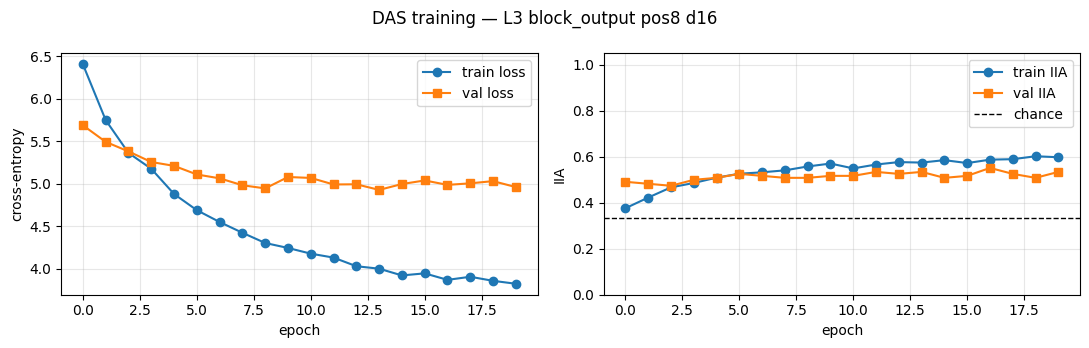

In [11]:
# ── Train DAS ──────────────────────────────────────────────────────────────
DIM        = 16
NUM_EPOCHS = 20

torch.manual_seed(SEED)
cfg = make_das_config(model, layer=BEST_LAYER, component=COMPONENT,
                      intervention_dim=DIM, unit="pos")
das_out = train_das_alignment(
    model, tokenizer, train_ds_f, cfg,
    num_epochs=NUM_EPOCHS, lr=1e-3, batch_size=8,
    device=DEVICE, verbalizer=verbalizer,
    fixed_position=FIXED_POSITION,
    eval_cf_dataset=eval_ds_f,    # logs val loss + val IIA every epoch
    progress=True,
)

# Training curve
hist = pd.DataFrame(das_out.history)
print("\nLast 3 epochs:")
print(hist.tail(3).to_string(index=False))

fig, ax = plt.subplots(1, 2, figsize=(11, 3.5))
ax[0].plot(hist["epoch"], hist["loss"], marker="o", label="train loss")
if "val_loss" in hist.columns: ax[0].plot(hist["epoch"], hist["val_loss"], marker="s", label="val loss")
ax[0].set_xlabel("epoch"); ax[0].set_ylabel("cross-entropy"); ax[0].legend(); ax[0].grid(alpha=0.3)
ax[1].plot(hist["epoch"], hist["train_iia"], marker="o", label="train IIA")
if "val_iia" in hist.columns: ax[1].plot(hist["epoch"], hist["val_iia"], marker="s", label="val IIA")
ax[1].axhline(1/3, color="black", linestyle="--", lw=1, label="chance")
ax[1].set_xlabel("epoch"); ax[1].set_ylabel("IIA"); ax[1].set_ylim(0, 1.05); ax[1].legend(); ax[1].grid(alpha=0.3)
fig.suptitle(f"DAS training — L{BEST_LAYER} {COMPONENT} pos{FIXED_POSITION} d{DIM}")
fig.tight_layout(); fig.savefig("outputs/figures/lexical_das_training.png", dpi=150, bbox_inches="tight")
plt.show()


     condition   IIA
   Trained DAS 0.534
 Random-source 0.578
Wrong-variable 0.216

Factual accuracy (base prediction, no intervention): 0.388
Verbalizer-hit rate (unrestricted top-token is yes/no/maybe): 0.000


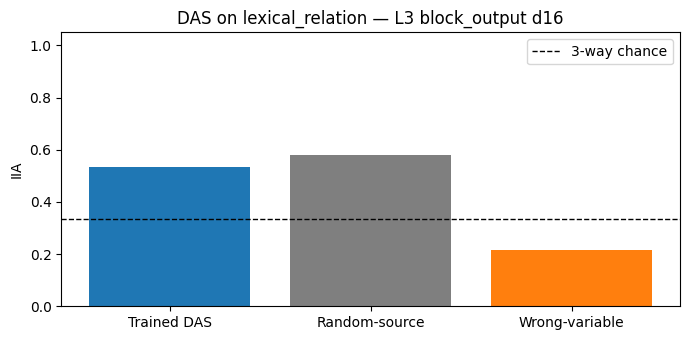

In [12]:
# ── Evaluate against the two controls ──────────────────────────────────────
res        = evaluate_das_iia(das_out.intervenable, eval_ds_f, tokenizer,
                              device=DEVICE, verbalizer=verbalizer, fixed_position=FIXED_POSITION)
res_random = evaluate_das_iia(das_out.intervenable, eval_random_f, tokenizer,
                              device=DEVICE, verbalizer=verbalizer, fixed_position=FIXED_POSITION)
res_wrong  = evaluate_das_iia(das_out.intervenable, eval_wrong_f,  tokenizer,
                              device=DEVICE, verbalizer=verbalizer, fixed_position=FIXED_POSITION)

summary = pd.DataFrame([
    {"condition": "Trained DAS",     "IIA": res["iia"]},
    {"condition": "Random-source",   "IIA": res_random["iia"]},
    {"condition": "Wrong-variable",  "IIA": res_wrong["iia"]},
]).round(3)
print(summary.to_string(index=False))
summary.to_csv("outputs/tables/lexical_relation_summary.csv", index=False)
print(f"\nFactual accuracy (base prediction, no intervention): {res['factual_accuracy']:.3f}")
print(f"Verbalizer-hit rate (unrestricted top-token is yes/no/maybe): {res['verbalizer_hit_rate']:.3f}")

fig, ax = plt.subplots(figsize=(7, 3.5))
colors = ["tab:blue", "tab:gray", "tab:orange"]
ax.bar(summary["condition"], summary["IIA"], color=colors)
ax.axhline(1/3, color="black", linestyle="--", lw=1, label="3-way chance")
ax.set_ylabel("IIA"); ax.set_ylim(0, 1.05)
ax.set_title(f"DAS on lexical_relation — L{BEST_LAYER} {COMPONENT} d{DIM}")
ax.legend(); fig.tight_layout()
fig.savefig("outputs/figures/lexical_relation_bars.png", dpi=150, bbox_inches="tight")
plt.show()


**Interpreting the result.** If DAS is doing what we expect:

- **Trained DAS IIA** should be substantially above chance (typically 0.6–0.75 for GPT-2 on this task).
- **Random-source IIA** should drop close to chance — the rotation does transport the source's `lexical_relation` value, but a *random* source's value is random with respect to the base, so the patched prediction has nothing to do with the symbolic counterfactual label.
- **Wrong-variable IIA** should also drop — the rotation transports `lexical_relation`, not `premise_word_identity`, so evaluating against the wrong gold labels gives random performance.

The gap between trained DAS and these two controls is the actual evidence that the learned subspace specifically encodes the target variable. **IIA alone is not enough.**

---
## 8. A second variable — `monotonicity`

The strongest evidence that DAS isn't just curve-fitting is to find *another* high-level variable in the same model at a *different* intervention site. `monotonicity` is a natural choice: it's the upward/downward feature that flips `FORWARD` ↔ `REVERSE` under negation.

Two changes from the lexical_relation setup:

1. **Different intervention site.** Monotonicity is encoded in the determiner/quantifier ("A", "Some", "No", "not") — the *first* token of the prompt. We localize the intervention there.
2. **Different templates.** Source examples must come from the *opposite* monotonicity class so the intervention actually flips the variable. Base = upward template; source = downward template.

In [13]:
# ── Build the monotonicity counterfactual dataset ──────────────────────────
UP_T   = [UPWARD_TEMPLATES[0]]    # "A {word} is on the table."
DOWN_T = [DOWNWARD_TEMPLATES[0]]  # "No {word} is on the table."

mono_train = build_counterfactual_dataset(
    tokenizer, target_variable="monotonicity",
    pairs=train_pairs, templates=UP_T, source_templates=DOWN_T,
    n_examples=256, seed=SEED, require_label_change=True,
    require_monotonicity_flip=True,
)
mono_eval = build_counterfactual_dataset(
    tokenizer, target_variable="monotonicity",
    pairs=eval_pairs, templates=UP_T, source_templates=DOWN_T,
    n_examples=64, seed=SEED + 42, require_label_change=True,
    require_monotonicity_flip=True,
)

# Marker token position
MONO_POS = Counter(int(ex.intervention_pos) for ex in mono_train.examples).most_common(1)[0][0]
print(f"Monotonicity-marker token position: {MONO_POS}  (expect 0 — the determiner)")

mono_train = mono_train.filter_by_position(MONO_POS)
mono_eval  = mono_eval.filter_by_position(MONO_POS)
mono_eval_random = build_random_source_dataset(mono_eval, seed=SEED + 1)
mono_eval_wrong  = build_wrong_variable_dataset(mono_eval, wrong_variable="hypothesis_word_identity")
print(f"After filter:  train={len(mono_train)}  eval={len(mono_eval)}")
print(f"\nExample monotonicity pair:")
ex = mono_train.examples[0]
print(f"  base   : {ex.base.prompt!r}")
print(f"  source : {ex.source.prompt!r}")
print(f"  patch  : token pos {ex.intervention_pos}  (the determiner)")
print(f"  cf_label: {['entailment','neutral','contradiction'][ex.counterfactual_label_id]}")


Monotonicity-marker token position: 0  (expect 0 — the determiner)
After filter:  train=256  eval=64

Example monotonicity pair:
  base   : 'A object is on the table. A axe is on the table. Answer:'
  source : 'No flower is on the table. No daisy is on the table. Answer:'
  patch  : token pos 0  (the determiner)
  cf_label: entailment


In [14]:
# ── Train DAS on monotonicity ──────────────────────────────────────────────
# We try an earlier layer (4) because monotonicity is more of a "syntactic" feature
# than the semantic lexical_relation — should be encoded shallower.
MONO_LAYER = 4
MONO_DIM   = 16

torch.manual_seed(SEED)
mono_cfg = make_das_config(model, layer=MONO_LAYER, component=COMPONENT,
                           intervention_dim=MONO_DIM, unit="pos")
mono_out = train_das_alignment(
    model, tokenizer, mono_train, mono_cfg,
    num_epochs=20, lr=1e-3, batch_size=8,
    device=DEVICE, verbalizer=verbalizer,
    fixed_position=MONO_POS,
    eval_cf_dataset=mono_eval,
    progress=True,
)

m_res   = evaluate_das_iia(mono_out.intervenable, mono_eval,        tokenizer,
                           device=DEVICE, verbalizer=verbalizer, fixed_position=MONO_POS)
m_res_r = evaluate_das_iia(mono_out.intervenable, mono_eval_random, tokenizer,
                           device=DEVICE, verbalizer=verbalizer, fixed_position=MONO_POS)
m_res_w = evaluate_das_iia(mono_out.intervenable, mono_eval_wrong,  tokenizer,
                           device=DEVICE, verbalizer=verbalizer, fixed_position=MONO_POS)

mono_summary = pd.DataFrame([
    {"condition": "Trained DAS",     "IIA": m_res["iia"]},
    {"condition": "Random-source",   "IIA": m_res_r["iia"]},
    {"condition": "Wrong-variable",  "IIA": m_res_w["iia"]},
]).round(3)
print(mono_summary.to_string(index=False))
mono_summary.to_csv("outputs/tables/monotonicity_summary.csv", index=False)


epochs:   0%|          | 0/20 [00:00<?, ?it/s]

epoch 0:   0%|          | 0/32 [00:00<?, ?it/s]

epoch 1:   0%|          | 0/32 [00:00<?, ?it/s]

epoch 2:   0%|          | 0/32 [00:00<?, ?it/s]

epoch 3:   0%|          | 0/32 [00:00<?, ?it/s]

...

epoch 16:   0%|          | 0/32 [00:00<?, ?it/s]

epoch 17:   0%|          | 0/32 [00:00<?, ?it/s]

epoch 18:   0%|          | 0/32 [00:00<?, ?it/s]

epoch 19:   0%|          | 0/32 [00:00<?, ?it/s]

     condition   IIA
   Trained DAS 0.438
 Random-source 0.438
Wrong-variable 0.016


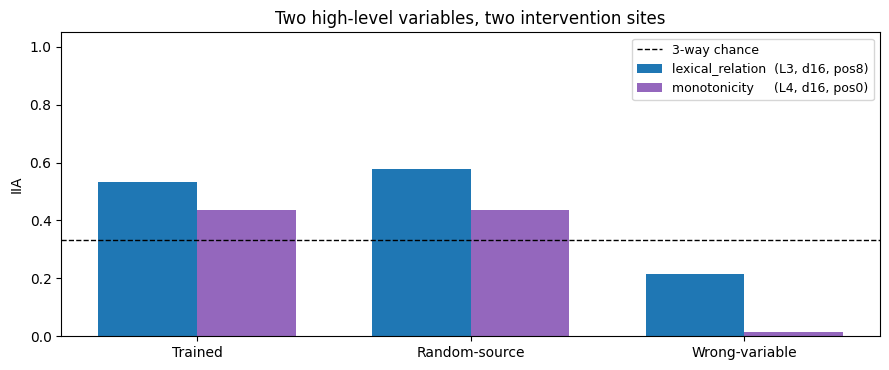

In [15]:
# ── Side-by-side: lexical_relation vs monotonicity ─────────────────────────
fig, ax = plt.subplots(figsize=(9, 3.8))
x = np.arange(3); width = 0.36
a_vals = [res["iia"], res_random["iia"], res_wrong["iia"]]
e_vals = [m_res["iia"], m_res_r["iia"], m_res_w["iia"]]
ax.bar(x - width/2, a_vals, width, color="tab:blue",
       label=f"lexical_relation  (L{BEST_LAYER}, d{DIM}, pos{FIXED_POSITION})")
ax.bar(x + width/2, e_vals, width, color="tab:purple",
       label=f"monotonicity     (L{MONO_LAYER}, d{MONO_DIM}, pos{MONO_POS})")
ax.set_xticks(x); ax.set_xticklabels(["Trained", "Random-source", "Wrong-variable"])
ax.axhline(1/3, color="black", linestyle="--", lw=1, label="3-way chance")
ax.set_ylabel("IIA"); ax.set_ylim(0, 1.05)
ax.set_title("Two high-level variables, two intervention sites")
ax.legend(loc="upper right", fontsize=9)
fig.tight_layout(); fig.savefig("outputs/figures/two_variables.png", dpi=150, bbox_inches="tight")
plt.show()


**Why this matters.** A single high-level variable can always be explained away as "DAS found *some* direction that correlates with whatever varies between base and source." Finding **two** variables, at two different intervention sites, with two different sets of controls, makes that explanation much harder to sustain — and it's the first hint that the model has *compositional* internal structure, which is exactly what we'll test in section 11.

---
## 9. MQNLI — a nested causal graph

🚧 **To be filled in next session.** This section introduces MQNLI (Multiply Quantified NLI; [Bowman et al. 2019](https://arxiv.org/abs/1911.00811)). Unlike our lexical task — a single intermediate variable — MQNLI has 33 variables arranged in a deep tree:

```
N_P_O, N_H_O  →  N_O               ┐
Adj_P_O, ...   →  Adj_O             │  object phrase
                  →  NP_O           │
Q_P_O, Q_H_O  →  Q_O                │
                  →  QP_O ─────────┐│
                                    │
…                                  →  NegP  →  QP_S  (final NLI label)
                                    │
NP_S, Q_S, Neg                    ──┘
```

We load the graph via `pyvene.CausalModel` and the 5 signature JSON files in `tutorial_data/` (downloaded by section 0).

In [16]:
print("Section 9: not yet implemented (Day 2 build target).")


Section 8: not yet implemented (Day 2 build target).


## 10. Fine-tuning GPT-2 on MQNLI

🚧 **To be filled in next session.** Per staff guidance, **factual accuracy must be > 90%** before DAS results are meaningful. The pyvene tutorial trains on only 100 examples × 1 epoch and reports ~17% factual accuracy — this is scaffolding, not a result. We train on ~10k examples × 10 epochs.

In [ ]:
print("Section 10: not yet implemented (Day 3 build target).")


## 11. DAS on MQNLI internal variables

🚧 **To be filled in next session.** Two intermediate variables:

- **`QP_S`** — the final label. Sanity check: patching the final-label representation should perfectly transport the label.
- **`NegP`** — first true intermediate variable. The interesting case: does GPT-2 encode the negation-applied phrase relation in a low-dim subspace?

In [ ]:
print("Section 11: not yet implemented (Day 4 build target).")


## 12. Composition — `do(NegP=src_A, QP_O=src_B)`

🚧 **The novel piece.** Train two DAS rotations *independently* (one for `NegP`, one for `QP_O`). Then at inference time, apply *both* interchange interventions simultaneously and compare the model's output to the symbolic `do(NegP=v_A, QP_O=v_B)` counterfactual.

If the two learned subspaces are genuinely disentangled, composition should match the symbolic prediction; if they overlap or interfere, the joint intervention will fail in interpretable ways.

In [ ]:
print("Section 11: not yet implemented (Day 4 build target).")


## 13. Calibration — random-init GPT-2 control

🚧 **The critique-aware section.** Following Makelov et al. (2023) and Sutter et al. (2025): an arbitrarily-flexible alignment map can produce nontrivial IIA on a *randomly-initialized* network with no learned task structure. We rerun the lexical-relation DAS at the same (layer, dim, position) on a freshly-initialized GPT-2 and report the IIA. If it's substantially above chance, that's evidence that *some* of the IIA we measured on trained GPT-2 is alignment capacity, not learned mechanism.

We use this to bound our claims: "DAS finds a subspace whose interventions match the symbolic counterfactual at IIA ≈ X. Random-init controls give IIA ≈ Y < X, so at least (X − Y) of the IIA can be attributed to learned structure."

---

## 13. Summary

🚧 **To be drafted.** Closing paragraph + table tying together: two variables on lexical NLI + composition on MQNLI + calibration result + limitations + future work (NDIF / 8B models / ScoNe).